# 1. Import All Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                             confusion_matrix)

# Tree models
import xgboost as xgb
import lightgbm as lgb

# SHAP explainability
import shap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Import Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mahendrapalsaniya/retail-cleaned-dataset/customer_segments.csv')
df.head()

,CustomerID,Recency,Frequency,Monetary,F_Score,R_Score,M_Score,RFM_Score,Segment,Churned_x,Churned_y,Churned,Cluster,Customer_Segment
0,12346,326,12,77556.46,5,2,5,4.000000,Loyal Customers,1,1,1,0,Potential Loyalists
1,12347,2,8,4921.53,4,5,5,4.666667,Champions,0,0,0,0,Potential Loyalists
2,12348,75,5,2019.40,4,3,4,3.666667,Potential Loyalists,0,0,0,0,Potential Loyalists
3,12349,19,4,4428.69,3,5,5,4.333333,Loyal Customers,0,0,0,0,Potential Loyalists
4,12350,310,1,334.40,1,2,2,1.666667,Lost,1,1,1,1,Lost Customers


In [3]:
print("Data loaded!")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nChurn distribution:")
print(df['Churned'].value_counts())
print(f"\nChurn rate: {df['Churned'].mean()*100:.1f}%")

Data loaded!
Shape: (5878, 14)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'F_Score', 'R_Score', 'M_Score', 'RFM_Score', 'Segment', 'Churned_x', 'Churned_y', 'Churned', 'Cluster', 'Customer_Segment']

Churn distribution:
Churned
1    2985
0    2893
Name: count, dtype: int64

Churn rate: 50.8%


# 3. Split Data for Prediction

In [4]:
# Features and target
X= df[['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']]
y   = df['Churned']
# Split — 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data split complete!")
print(f"  Training samples:  {len(X_train):,}")
print(f"  Testing samples:   {len(X_test):,}")
print()
print("Training churn rate:", round(y_train.mean()*100, 1), "%")
print("Testing churn rate: ", round(y_test.mean()*100, 1), "%")

Data split complete!
  Training samples:  4,702
  Testing samples:   1,176

Training churn rate: 50.8 %
Testing churn rate:  50.8 %


# 4. Training XGBoost 

In [5]:
# XGBoost parameters
xgb_params = {
    'n_estimators'    : 300,
    'max_depth'       : 5,
    'learning_rate'   : 0.05,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'random_state'    : 42,
    'eval_metric'     : 'logloss',
    'use_label_encoder': False
}

# Model Training
model = xgb.XGBClassifier(**xgb_params)

model.fit(X_train,y_train)
print('XGBoost Model Trained!\n')

# Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print('Prediction Generated!\n')
print(f"  Sample predictions: {y_pred[:10].tolist()}")
print(f"  Sample probabilities: {[round(p,2) for p in y_prob[:10]]}")

XGBoost Model Trained!

Prediction Generated!

  Sample predictions: [0, 1, 0, 1, 1, 1, 0, 0, 1, 1]
  Sample probabilities: [np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(1.0)]


In [6]:
xgb_report = classification_report(y_test,y_pred,target_names=['Active','Churned'])
xgb_auc = roc_auc_score(y_test,y_prob)
xgb_accuracy = accuracy_score(y_test,y_pred)

print("REPORT :\n")
print(xgb_report)
print(f"   AUC-ROC  : {xgb_auc:.4f}")
print(f"   Accuracy : {xgb_accuracy:.4f}")



REPORT :

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       579
     Churned       1.00      1.00      1.00       597

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

   AUC-ROC  : 1.0000
   Accuracy : 1.0000


### XGBoost Feature Importance

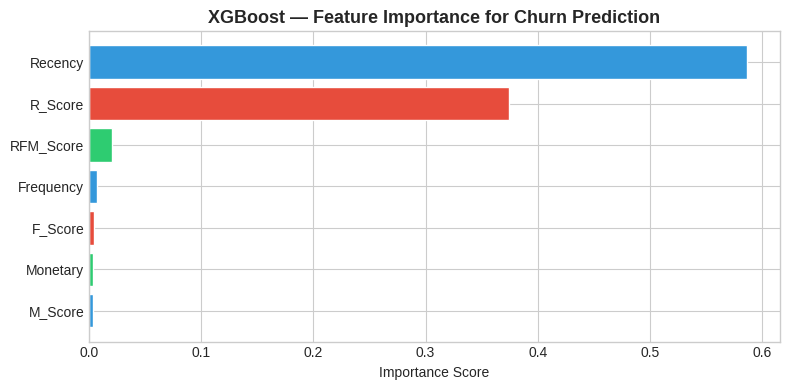

Feature Importance:
  M_Score      0.0033
  Monetary     0.0034
  F_Score      0.0044
  Frequency    0.0071
  RFM_Score    0.0205
  R_Score      0.3745
  Recency      0.5868


In [7]:
# Feature importance
feature_names = X.columns

imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
bars = plt.barh(imp['Feature'], imp['Importance'],
                color=['#3498db','#2ecc71','#e74c3c'], edgecolor='white')
plt.title('XGBoost — Feature Importance for Churn Prediction',
          fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('churn_feature_importance.png', dpi=150)
plt.show()

print("Feature Importance:")
for _, row in imp.iterrows():
    print(f"  {row['Feature']:<12} {row['Importance']:.4f}")

# 5. Training LightGBM

In [8]:
# LightGBM Parameters
lgb_params = {
    'n_estimators'  : 300,
    'max_depth'     : 5,
    'learning_rate' : 0.05,
    'subsample'     : 0.8,
    'random_state'  : 42,
    'verbose'       : -1
}

# Model Training
model1 = lgb.LGBMClassifier(**lgb_params)

model1.fit(X_train,y_train)
print('LightGBM Model Trained!\n')

# Prediction
y_pred1 = model1.predict(X_test)
y_prob1 = model1.predict_proba(X_test)[:,1]

print('Prediction Generated!\n')
print(f"  Sample predictions: {y_pred1[:10].tolist()}")
print(f"  Sample probabilities: {[round(p,2) for p in y_prob1[:10]]}")

LightGBM Model Trained!

Prediction Generated!

  Sample predictions: [0, 1, 0, 1, 1, 1, 0, 0, 1, 1]
  Sample probabilities: [np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]


In [9]:
lgb_report = classification_report(y_test,y_pred1,target_names=['Active','Churned'])
lgb_auc = roc_auc_score(y_test,y_prob1)
lgb_accuracy = accuracy_score(y_test,y_pred1)

print("REPORT :\n")
print(xgb_report)
print(f"   AUC-ROC  : {lgb_auc:.4f}")
print(f"   Accuracy : {lgb_accuracy:.4f}")

REPORT :

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       579
     Churned       1.00      1.00      1.00       597

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

   AUC-ROC  : 1.0000
   Accuracy : 0.9974


### LightGBM Feature Importance

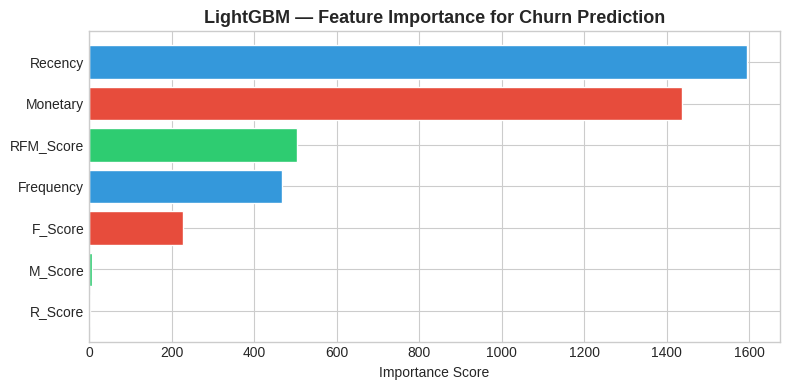

Feature Importance:
  R_Score      1.0000
  M_Score      7.0000
  F_Score      228.0000
  Frequency    467.0000
  RFM_Score    505.0000
  Monetary     1436.0000
  Recency      1595.0000


In [10]:
# Feature importance
feature_names = X.columns

important = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model1.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
bars = plt.barh(important['Feature'], important['Importance'],
                color=['#3498db','#2ecc71','#e74c3c'], edgecolor='white')
plt.title('LightGBM — Feature Importance for Churn Prediction',
          fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('churn_feature_importance_lgb.png', dpi=150)
plt.show()

print("Feature Importance:")
for _, row in important.iterrows():
    print(f"  {row['Feature']:<12} {row['Importance']:.4f}")

# 6. Comparing both Models

In [11]:
# Compare LightGBM and XGBoost

print("MODEL COMPARISON — CHURN PREDICTION\n")
print(f"{'Model':<15} {'AUC-ROC':<12} {'Accuracy':<12}")
print(f"{'XGBoost':<15} {xgb_auc:<12.4f} {xgb_accuracy:<12.4f}")
print(f"{'LightGBM':<15} {lgb_auc:<12.4f} {lgb_accuracy:<12.4f}\n")

# Select best model based on AUC-ROC
if xgb_auc >= lgb_auc:
    best_model   = model
    best_proba   = y_prob
    best_pred    = y_pred
    best_name    = "XGBoost"
    best_auc     = xgb_auc
else:
    best_model   = model1
    best_proba   = y_prob1
    best_pred    = y_pred1
    best_name    = "LightGBM"
    best_auc     = lgb_auc

print(f"\n🏆 Best Model: {best_name} (AUC-ROC: {best_auc:.4f})")

MODEL COMPARISON — CHURN PREDICTION

Model           AUC-ROC      Accuracy    
XGBoost         1.0000       1.0000      
LightGBM        1.0000       0.9974      


🏆 Best Model: XGBoost (AUC-ROC: 1.0000)


### Confusion Matrix

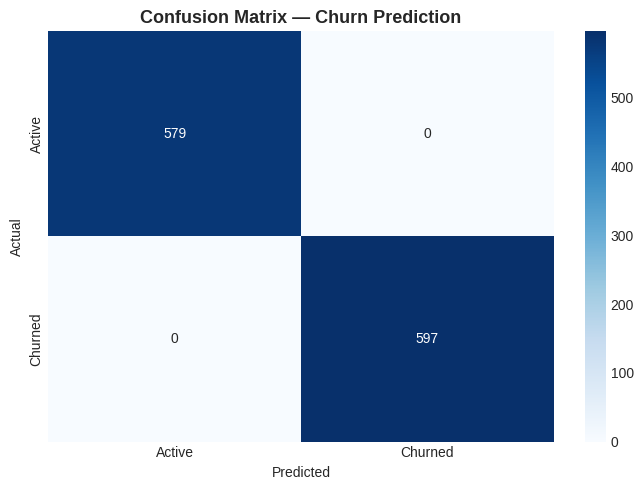

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'])
plt.title('Confusion Matrix — Churn Prediction', fontweight='bold', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('churn_confusion_matrix.png', dpi=150)
plt.show()

# 7. SHAP Explainability

In [13]:
# SHAP Explainability

# Create SHAP explainer for the best model
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # LightGBM returns list
else:
    shap_vals = shap_values     # XGBoost returns array

print(shap_vals)

[[-6.5251980e+00  1.6333165e-02 -3.0970145e-03 ...  1.6843695e-02
  -3.2624956e-03 -4.0118787e-01]
 [ 6.4925418e+00  1.4280249e-02  4.1817963e-02 ...  1.1547040e-02
   2.5724119e-03  1.5297075e-01]
 [-6.5251980e+00 -6.2272966e-02  1.5621975e-02 ... -1.2307143e-02
   2.3336760e-03  1.6964661e-01]
 ...
 [-6.5251980e+00  9.5666666e-04 -7.6336833e-04 ...  1.1200904e-02
  -3.4356336e-03 -3.9045075e-01]
 [-6.5251980e+00 -1.1324912e-02 -2.4456620e-02 ...  3.7244838e-03
  -1.5990899e-03 -3.0374584e-01]
 [-6.5251980e+00 -3.8144283e-02 -4.3795764e-02 ... -1.8990301e-02
   6.9831810e-03  6.9534056e-02]]


# 8. Save Model

In [14]:
joblib.dump(best_model,'churn_model.pkl')
joblib.dump(X,'churn_features.pkl')
print("best model is saved!")

best model is saved!
